# Preliminar Exploratory Data Analysis

# Preliminari

In [198]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import json
import ast
from pprint import pprint

In [199]:
# Parametri
RAW_DATA_FILE_NAME = 'base.tumoreprimitivo_finale.csv'

In [200]:
# Set plot style
plt.style.use('ggplot')
#sns.set_palette('hls')
base_dir = Path.cwd().parent
print(f'{base_dir = }')

base_dir = WindowsPath('c:/Users/lucat/PythonRepositories/PRIN')


# Load Data

In [201]:
# Get data
data_path = base_dir / 'data' / RAW_DATA_FILE_NAME
data = pd.read_csv(data_path)
data.sort_values(by='id', inplace=True, ignore_index=True)
print(f'{data.shape = }')
display(data.head(2))
pprint(data.iloc[0])

data.shape = (343, 45)


,id,profile,discrepanze_rilevate,motivazioni_discrepanze,radiologist,patient_id,sesso,data_nascita,interpretazioni,report_text,...,coinvolgimento_fascia_mesorettale,distanza_minima_fascia_ore,linfonodi_sospetti,numero_linfonodi_non_conosciuto,sedi_locoregionali,sedi_non_locoregionali,depositi_tumorali,numero_depositi,emvi_esteso,status
0,44,IlariaNacci,['nessuna'],nessuna,Barbaro,5667889,M,1976-04-12,dsfgsfsgf,RM SCAVO PELVICO (S/C MDC)\nEsame eseguito med...,...,si,NaN,6.0,False,[],[],si,0.0,no,complete
1,46,GuidoImbemba,['nessuna'],nessuna,Guerrieri Daniele,236893,F,1937-10-08,NaN,"NEL RETTO MEDIO, A CIRCA 7 CM DAL MARGINE ANAL...",...,no,NaN,0.0,True,"['mesorettali', 'sacrali', 'otturatori', 'rett...",[],no,0.0,no,complete


id                                                                                       44
profile                                                                         IlariaNacci
discrepanze_rilevate                                                            ['nessuna']
motivazioni_discrepanze                                                             nessuna
radiologist                                                                         Barbaro
patient_id                                                                          5667889
sesso                                                                                     M
data_nascita                                                                     1976-04-12
interpretazioni                                                                   dsfgsfsgf
report_text                               RM SCAVO PELVICO (S/C MDC)\nEsame eseguito med...
morfologia                                                                      

In [202]:
# Referti poco chiari. Sono quelli che hanno la stringa "escludere".
for i, r in data[data['interpretazioni'].str.contains("escludere", case=False, na=False)].iterrows():
    print(f"*--- id referto: {r['id']}\ninterpretazione: {r['interpretazioni']}\n{100*'-'}")

*--- id referto: 171
interpretazione: FORSE DA ESCLUDERE; REFERTO NON CHIARO

la formazione nodulare è digitazione della neoplasia o linfonodo? in base a questo va compilato. 

non si può sapere se non rivedendo immagini, anche per linfonodi non è chiaro se sono sospetti o no, 
----------------------------------------------------------------------------------------------------
*--- id referto: 259
interpretazione: POCHE INFO; FORSE DA ESCLUDERE

55 mm che misura è? 
credo possa riferirsi a diametro assiale massimo
----------------------------------------------------------------------------------------------------


# Pulisci dati

In [203]:
# Rimuovi righe duplicate
print(f'Shape iniziale: {data.shape}')

# Intere righe duplicate. Keep last perchè i report hanno id crescente
duplicati = data.iloc[:, 1:].duplicated(keep='last')
print(f'Numero righe duplicate: {duplicati.sum()}')

data_clean = data[duplicati == False]
print('Righe doppie eliminate')


Shape iniziale: (343, 45)
Numero righe duplicate: 2
Righe doppie eliminate


In [204]:
# Rimuovi righe con report duplicati
duplicati = data_clean['report_text'].duplicated(keep='last')
righe_report_duplicato = data_clean[duplicati]
print(f'Numero righe con stesso referto: {duplicati.sum()}')

data_clean = data_clean[duplicati == False]
print('Righe eliminate')

data_clean.reset_index(inplace=True, drop=True)

print(f'{data_clean.shape = }')

Numero righe con stesso referto: 22
Righe eliminate
data_clean.shape = (319, 45)


In [205]:
# !!! Anomalia. Numero depositi non può essere negativo.
data_clean[
    (data_clean['numero_depositi'] < 0)
    ][
         ['id', 'profile', 'depositi_tumorali', 'numero_depositi']
    ]

,id,profile,depositi_tumorali,numero_depositi
38,95,GuidoImbemba,no,-1.0
40,98,GuidoImbemba,no,-1.0
70,132,PietroPaoloAzzaro,no,-1.0
98,171,GuidoImbemba,no,-1.0
100,173,GuidoImbemba,no,-1.0


In [206]:
# Sostituiamo valore -1 con 0 per la colonna numero depositi
data_clean.loc[data_clean['numero_depositi'] == -1.0, 'numero_depositi'] = 0.0

In [207]:
# !!! Anomalia. Se i linfonodi sospetti sono 0, non possso avere le sedi valorizzate.
data_clean[
    (data_clean['linfonodi_sospetti'] == 0) &
    (data_clean['numero_linfonodi_non_conosciuto'] == False) &
    (data_clean['sedi_locoregionali'] != '[]')
    ][
         ['id', 'profile', 'numero_linfonodi_non_conosciuto', 'linfonodi_sospetti', 'sedi_locoregionali']
    ]

,id,profile,numero_linfonodi_non_conosciuto,linfonodi_sospetti,sedi_locoregionali
7,55,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'rettali_superiori']"
48,107,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'rettali_superiori']"
60,120,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'otturatori', 'iliaci_interni'..."
63,125,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'iliaci_interni']"
66,128,PietroPaoloAzzaro,False,0.0,['mesorettali']
67,129,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'rettali_superiori']"
68,130,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'otturatori']"
69,131,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'rettali_superiori']"
70,132,PietroPaoloAzzaro,False,0.0,"['mesorettali', 'otturatori', 'rettali_superio..."
71,133,PietroPaoloAzzaro,False,0.0,['mesorettali']


Dando un'occhiata ai referti si osserva come il modo corretto per risolvere l'anomalia è quello di valorizzare a True il campo numero_linfonodi_non_conosciuto.

In [208]:
data_clean.loc[
    (data_clean['linfonodi_sospetti'] == 0) &
    (data_clean['numero_linfonodi_non_conosciuto'] == False) &
    (data_clean['sedi_locoregionali'] != '[]')
    , 'numero_linfonodi_non_conosciuto'
    ] = True

In [209]:
# !!! anomalia
data_clean[
    (data_clean['infiltrazione_organi_dettagli'] > '') &
    (data_clean['infiltrazione_organi_extra'] == 'no')
    ][
        ['id', 'profile', 'infiltrazione_organi_dettagli', 'infiltrazione_organi_extra']
    ]

,id,profile,infiltrazione_organi_dettagli,infiltrazione_organi_extra
0,44,IlariaNacci,[object Object],no
2,47,GuidoImbemba,{'pavimento_pelvico': False},no
3,51,GuidoImbemba,{'pavimento_pelvico': False},no
5,53,PietroPaoloAzzaro,{'utero': True},no
6,54,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no
7,55,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no
8,56,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no
9,57,PietroPaoloAzzaro,{'altro': 'lungo i vasi emorroidari superiori....,no
11,59,GuidoImbemba,{'altro': ''},no
13,62,GuidoImbemba,{'altro': ''},no


In [210]:
# Sostituiamo i valore con None nella colonna dei dettagli degli organi coinvolti pechè altri valori non sono compatibili
# con "no" nella colonna infiltrazione_organi_extra.
data_clean.loc[
    (data_clean['infiltrazione_organi_dettagli'] > '') &
    (data_clean['infiltrazione_organi_extra'] == 'no')
    , 'infiltrazione_organi_dettagli'
    ] = None

In [211]:
# creazione nuova colonna "sedi_linfonodi_sospetti"
sedi_linfonodi = []
for s1, s2 in zip(data_clean.sedi_locoregionali, data_clean.sedi_non_locoregionali):
    sedi_linfonodi.append(str(ast.literal_eval(s1) + ast.literal_eval(s2)))
data_clean['sedi_linfonodi'] = sedi_linfonodi
data_clean[['sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']].head(15)

,sedi_locoregionali,sedi_non_locoregionali,sedi_linfonodi
0,[],[],[]
1,"['mesorettali', 'sacrali', 'otturatori', 'rett...",[],"['mesorettali', 'sacrali', 'otturatori', 'rett..."
2,[],[],[]
3,"['mesorettali', 'rettali_superiori']",[],"['mesorettali', 'rettali_superiori']"
4,['inguinali_sotto_dentata'],[],['inguinali_sotto_dentata']
5,['mesorettali'],"['iliaci_esterni', 'iliaci_comuni']","['mesorettali', 'iliaci_esterni', 'iliaci_comu..."
6,"['mesorettali', 'otturatori']",['iliaci_esterni'],"['mesorettali', 'otturatori', 'iliaci_esterni']"
7,"['mesorettali', 'rettali_superiori']",['iliaci_esterni'],"['mesorettali', 'rettali_superiori', 'iliaci_e..."
8,"['mesorettali', 'otturatori']",[],"['mesorettali', 'otturatori']"
9,"['mesorettali', 'iliaci_interni', 'otturatori'...",[],"['mesorettali', 'iliaci_interni', 'otturatori'..."


# Analisi preliminari delle colonne

In [212]:
print(data_clean.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319 entries, 0 to 318
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      319 non-null    int64  
 1   profile                                 319 non-null    object 
 2   discrepanze_rilevate                    319 non-null    object 
 3   motivazioni_discrepanze                 319 non-null    object 
 4   radiologist                             293 non-null    object 
 5   patient_id                              319 non-null    int64  
 6   sesso                                   317 non-null    object 
 7   data_nascita                            318 non-null    object 
 8   interpretazioni                         112 non-null    object 
 9   report_text                             319 non-null    object 
 10  morfologia                              317 non-null    object

In [213]:
# Fill NaN for plotting purposes
data_plot = data_clean.fillna('NaN')
data_ilaria = data_plot[data_plot['profile'] == 'IlariaNacci']
data_plot = data_plot.drop(index=data_plot[data_plot['profile'] == 'IlariaNacci'].index)
data_x = pd.concat([data_plot, data_ilaria])

In [214]:
# Radiologi che hanno scritto i referti.
data_x['radiologist'].value_counts()

radiologist
BARBARO PROF. BRUNELLA           80
Barbaro Brunella                 73
NaN                              26
BRIZI DOTT. MARIA GABRIELLA      16
DE GAETANO DOTT. ANNA MARIA      13
Brizi Maria Gabriella            12
De Gaetano Anna Maria            11
Macis Giuseppe                    9
MACIS DOTT. GIUSEPPE              8
Summaria Vincenzo                 6
GUI DOTT. BENEDETTA               5
Genco Enza                        5
GENCO DOTT.SSA ENZA               5
MINORDI DOTT. LAURA MARIA         4
D'AMBRA DOTT.SSA GIULIA           3
RODOLFINO DOTT.SSA ELENA          3
Minordi Laura Maria               3
MANFREDI PROF. RICCARDO           3
AVESANI DOTT. GIACOMO             3
Panico Camilla                    3
Guerrieri Daniele                 2
Manfredi Riccardo                 2
Avesani Giacomo                   2
Di Paola Valerio                  2
Carano Davide                     2
Rodolfino Elena                   2
Micco' Maura                      1
Petta Federica  

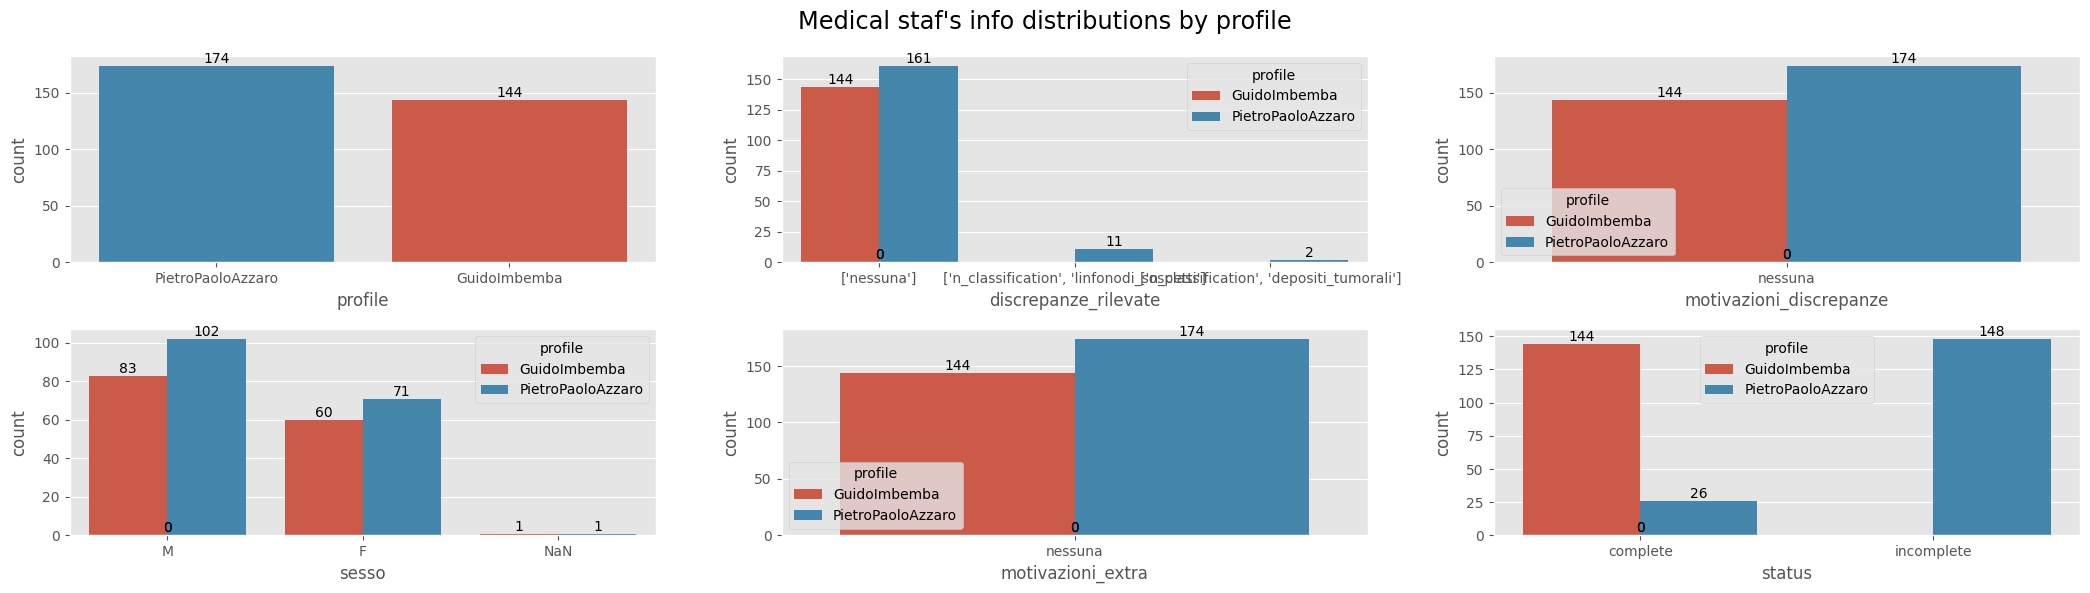

In [215]:
columns_plot = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'sesso', 'motivazioni_extra', 'status']
#columns_plot = ['profile', 'status']
hue_column = 'profile'

include_ilaria = False
print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions by profile", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]
    if include_ilaria:
        sns.countplot(data=data_x, x=col, order=data_x[col].value_counts().index, ax=ax, hue=hue_column)
    else:
        sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    columns = ['profile', 'discrepanze_rilevate', 'motivazioni_discrepanze', 'radiologist', 'sesso', 'motivazioni_extra', 'status']
    print(f'{len(columns) = }\n')
    for col in columns:
        print(data_clean[col].value_counts().to_frame().T)
        print("\n")

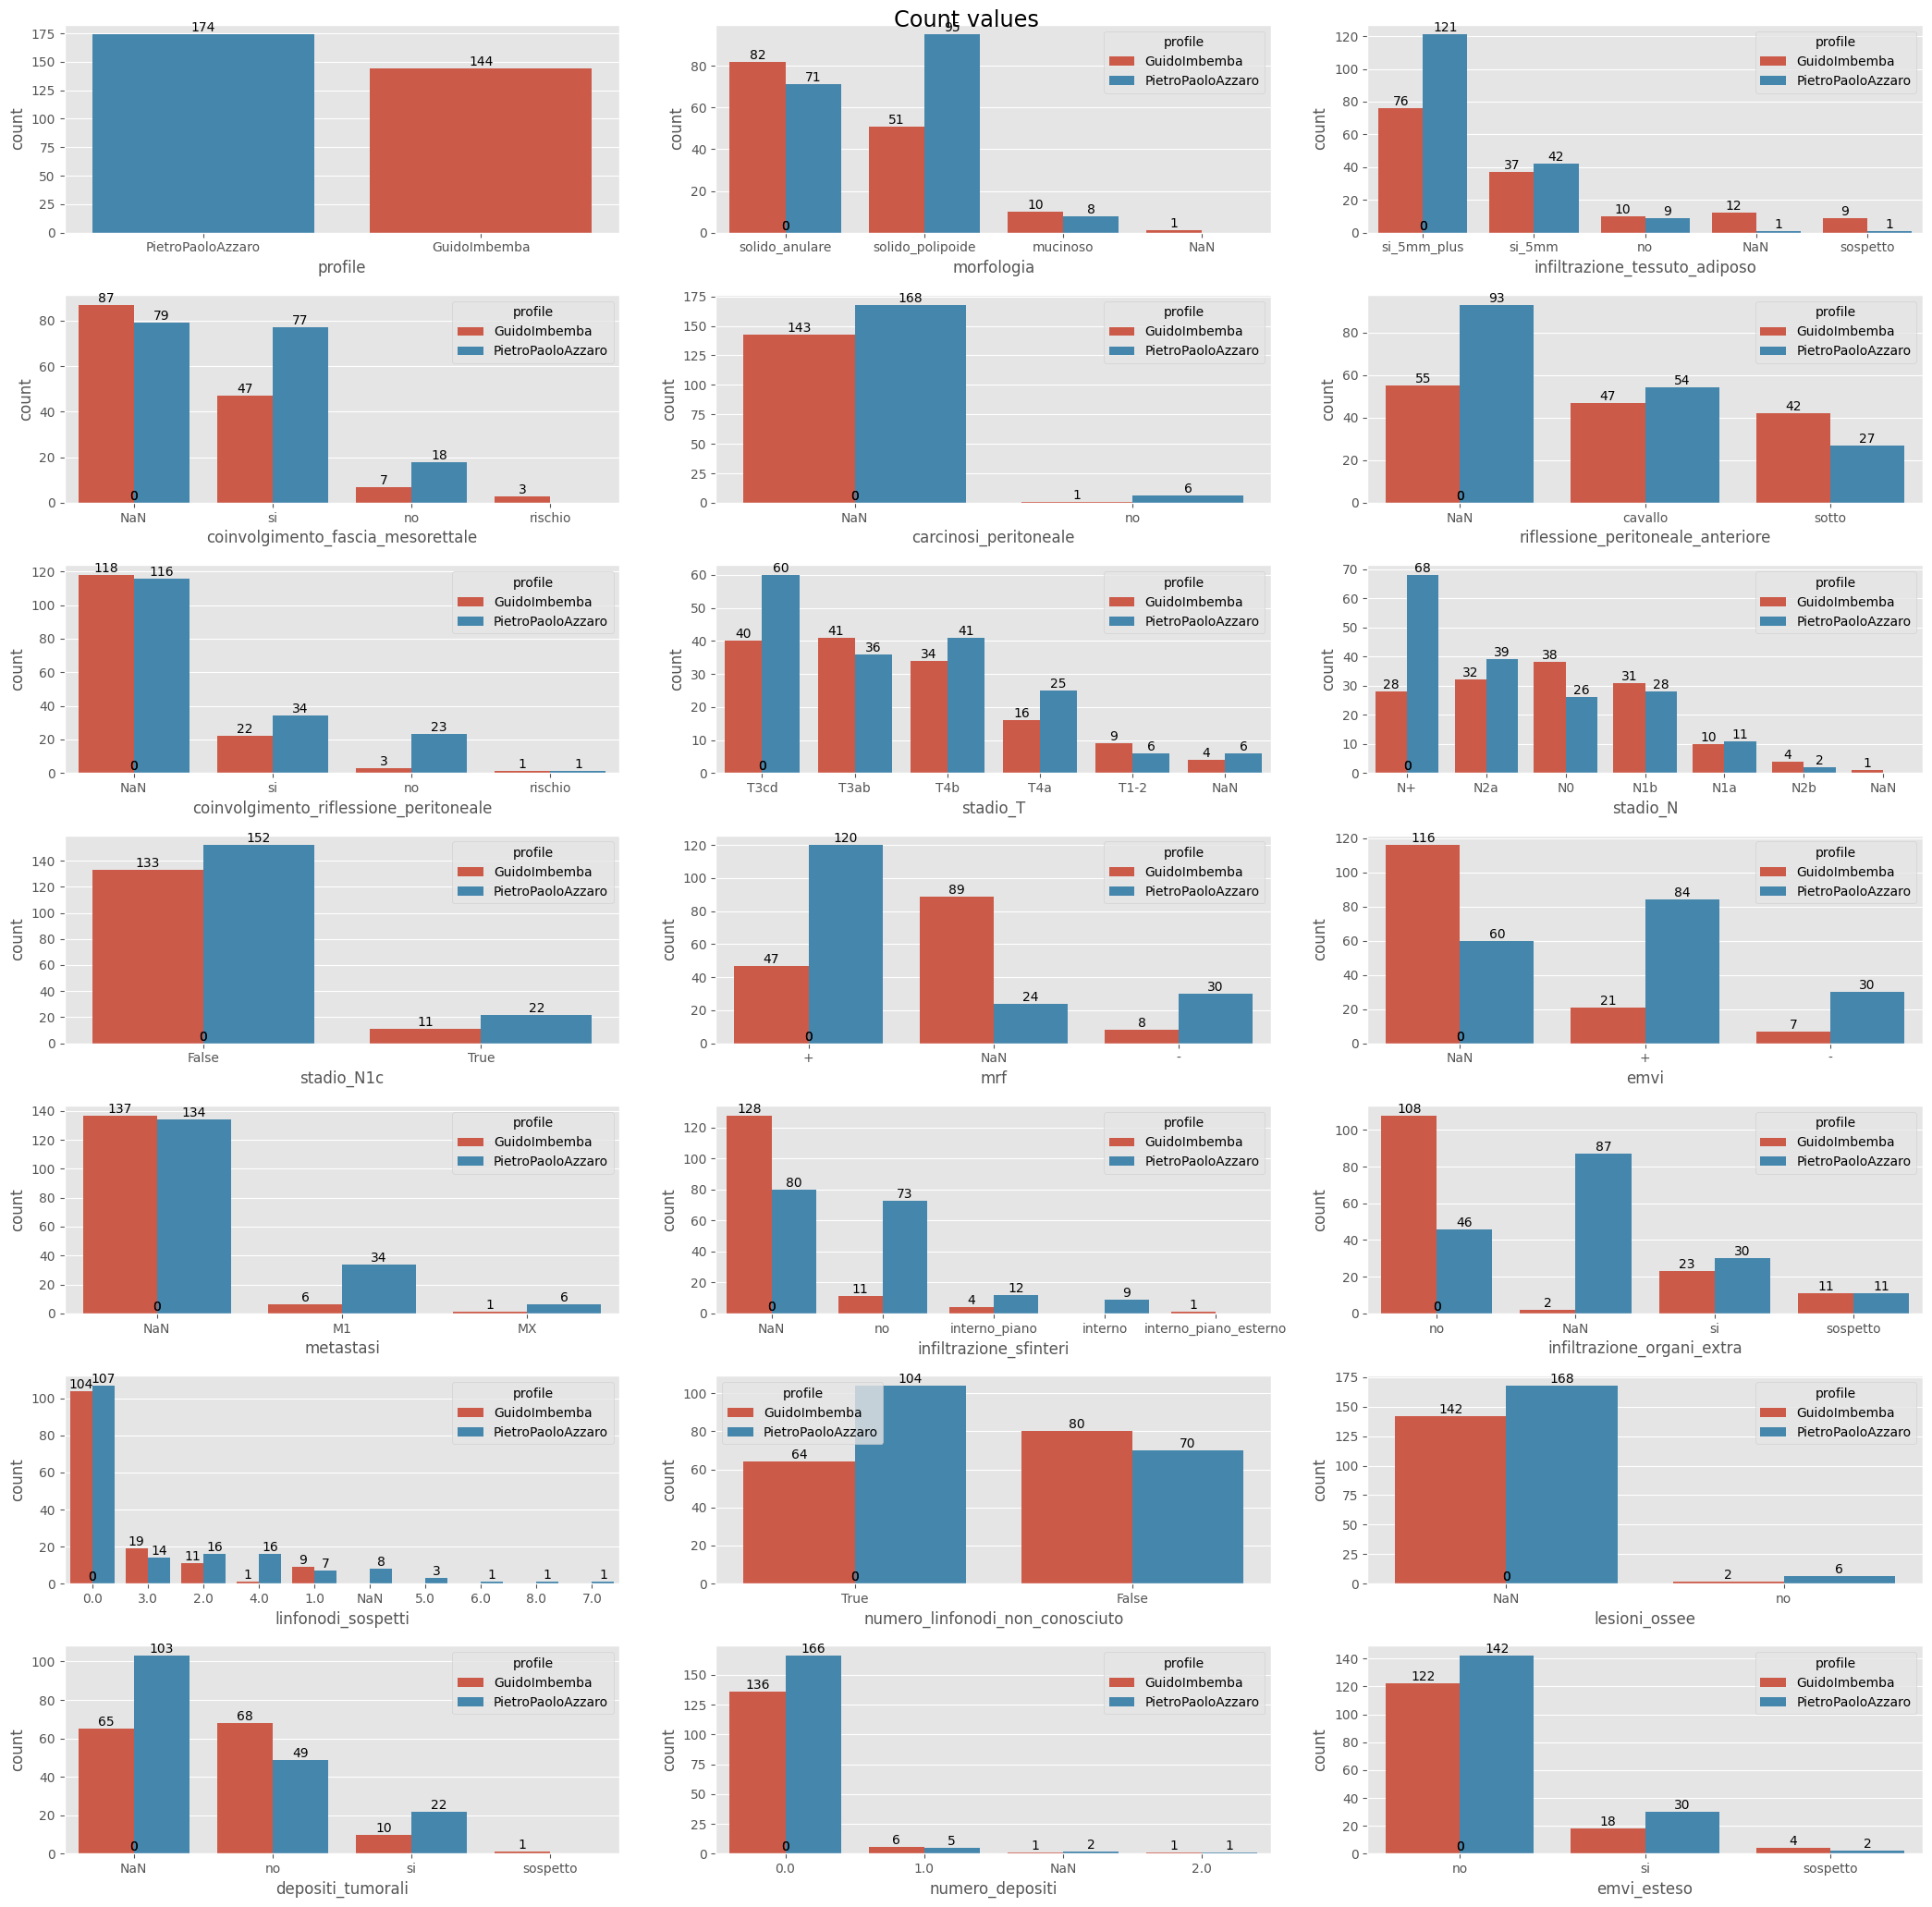

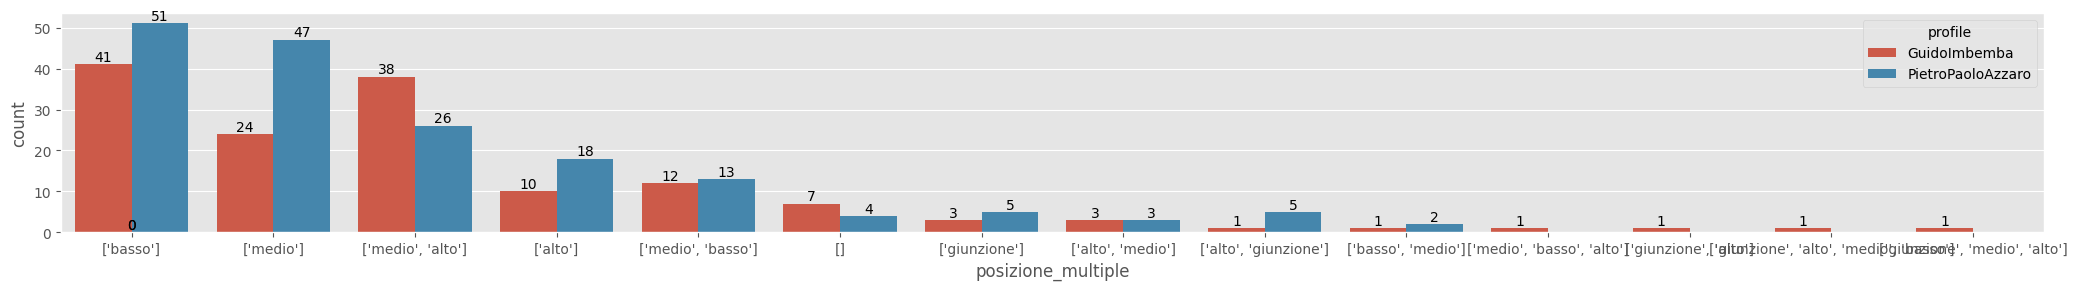

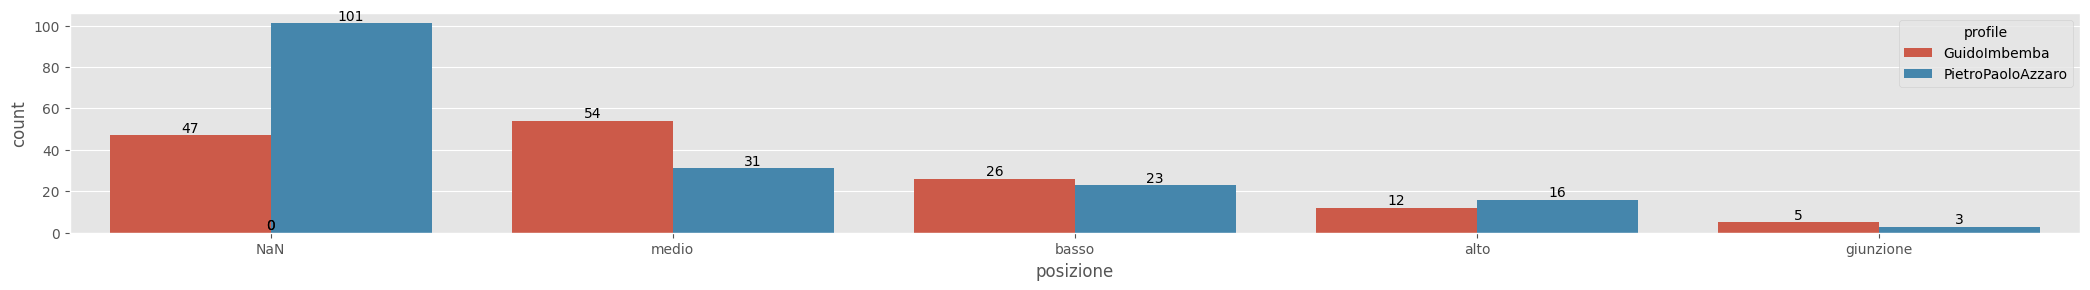

In [216]:
columns_plot = ['profile', 'morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = 'depositi_tumorali'
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione_multiple', order=data_plot['posizione_multiple'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(21, 3))
sns.countplot(data=data_plot, x='posizione', order=data_plot['posizione'].value_counts().index, ax=ax, hue='profile')
# Add values on top of bars
for p in ax.patches:
    y_text = int(p.get_height())
    x_text = p.get_x() + p.get_width() / 2
    ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

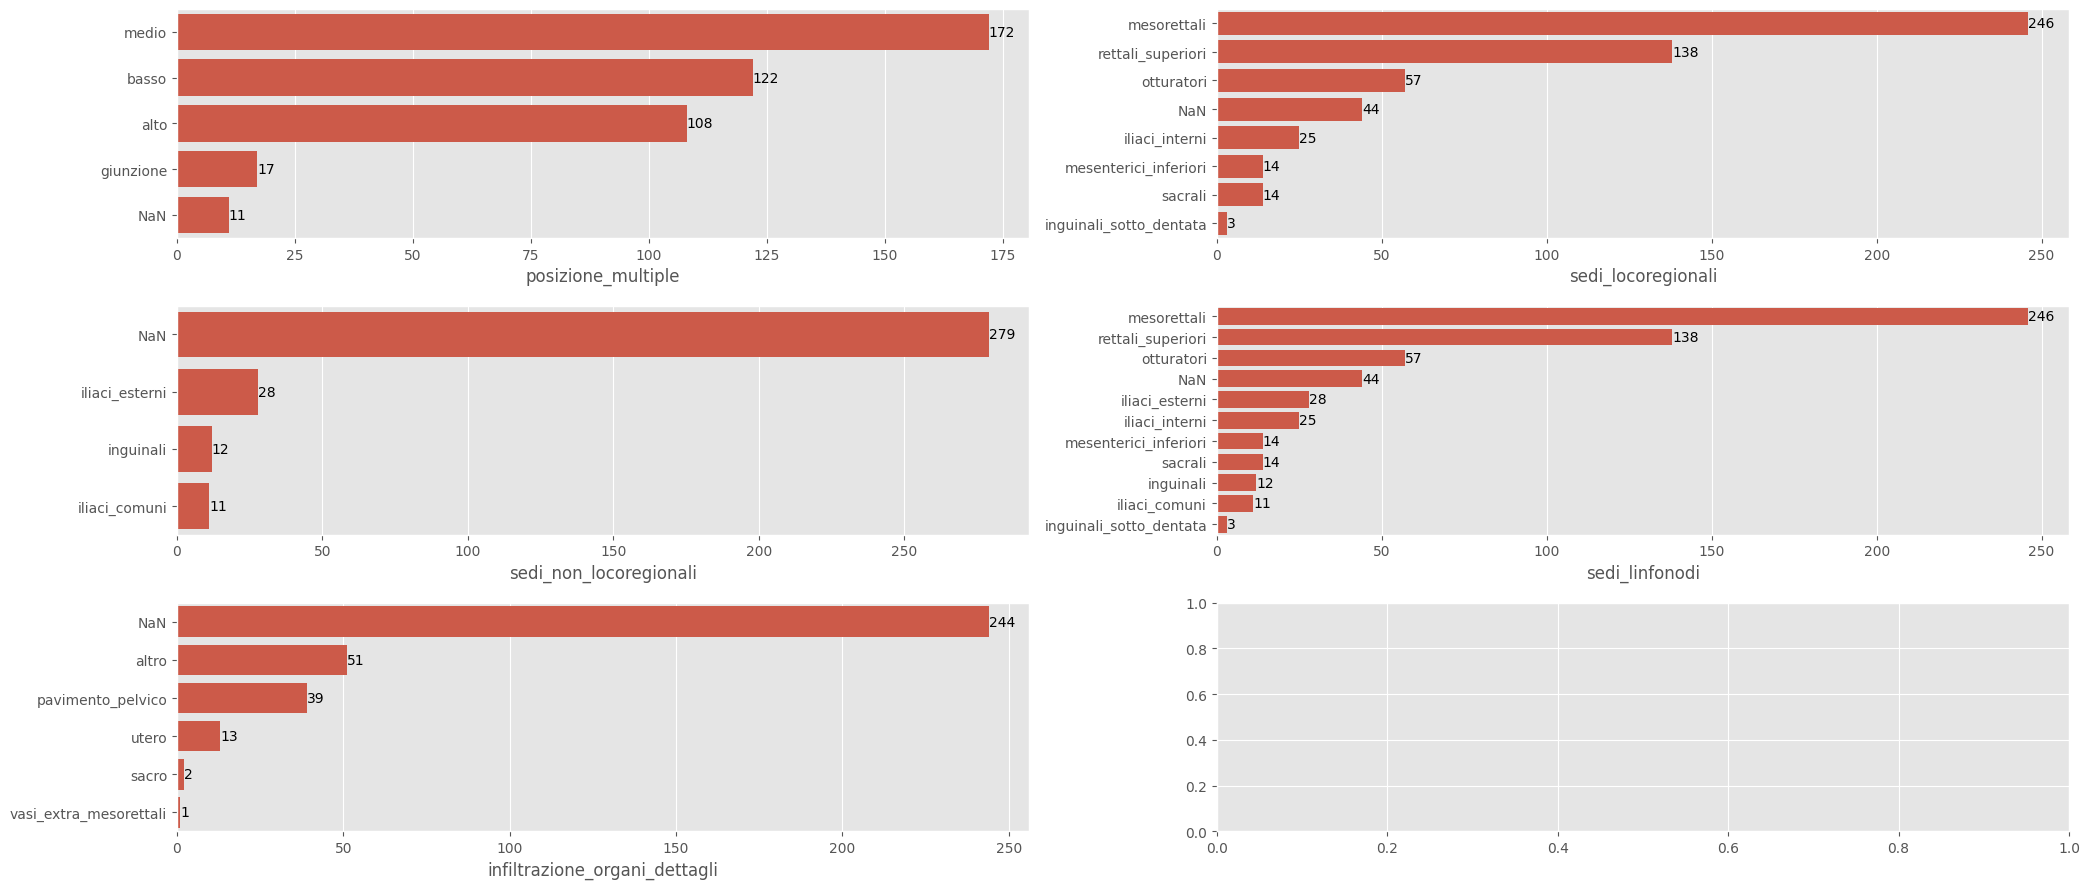

In [217]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
            
# Dettagli organi
dettagli_organi = {'NaN'}
altri_organi = set()
for s in data_x.infiltrazione_organi_dettagli.fillna('NaN').value_counts().index:
    if s != 'NaN' and s != 'nan':
        d = ast.literal_eval(s)
        #print('---')
        dettagli_organi.update(d.keys())
        if 'altro' in d:
            altri_organi.add(d['altro'])
            
dettagli_organi_counts = {val: 0 for val in dettagli_organi}
for s in data_x.infiltrazione_organi_dettagli.fillna('NaN'):
    if s == 'NaN' or s == 'nan':
        dettagli_organi_counts['NaN'] += 1
    else:
        d = ast.literal_eval(s)
        for key in dettagli_organi:
            if key in d:
                dettagli_organi_counts[key] += 1

counts['infiltrazione_organi_dettagli'] = dettagli_organi_counts
columns.append('infiltrazione_organi_dettagli')
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

**We see many anomalies between Guido and Pietro style of annotation. For this reason and also for what Ilaria told us, we will take into consideration only reports annotated by Guido**

# Guido's rows

In [218]:
data_clean_guido = data_clean[data_clean['profile'] == 'GuidoImbemba'].copy(deep=True)
data_clean_guido.reset_index(inplace=True, drop=True)
data_plot = data_clean_guido.fillna('NaN')

print(data_clean_guido.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      144 non-null    int64  
 1   profile                                 144 non-null    object 
 2   discrepanze_rilevate                    144 non-null    object 
 3   motivazioni_discrepanze                 144 non-null    object 
 4   radiologist                             144 non-null    object 
 5   patient_id                              144 non-null    int64  
 6   sesso                                   143 non-null    object 
 7   data_nascita                            144 non-null    object 
 8   interpretazioni                         59 non-null     object 
 9   report_text                             144 non-null    object 
 10  morfologia                              143 non-null    object

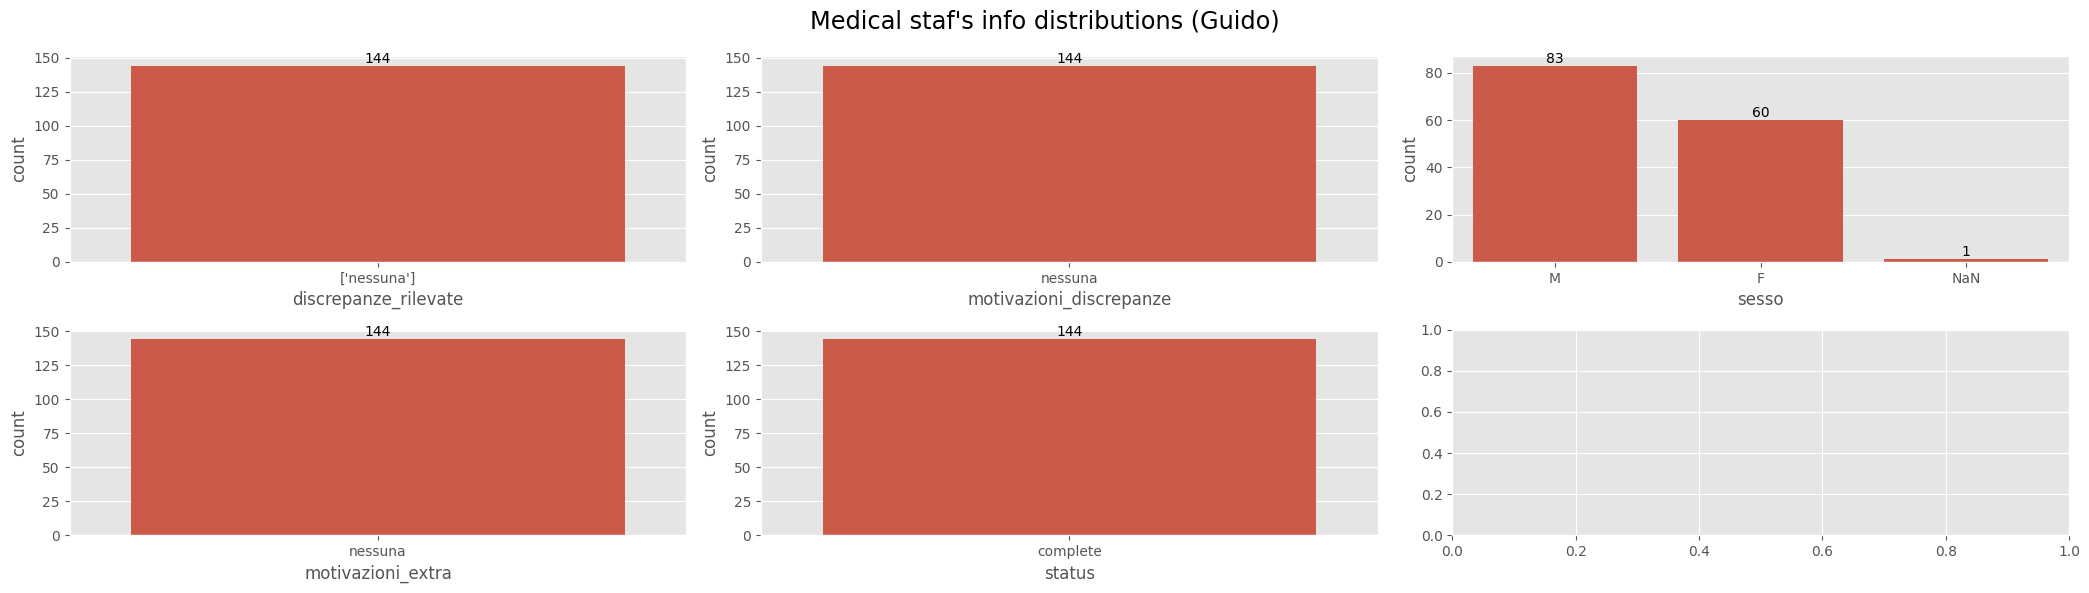

In [219]:
columns_plot = ['discrepanze_rilevate', 'motivazioni_discrepanze', 'sesso', 'motivazioni_extra', 'status']

print_statistics = False

n_columns = min(3, len(columns_plot))
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1

fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Medical staf's info distributions (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    if n_rows == 1:
        ax = axes[i]
    else:
        ax=axes[i//n_columns][i%n_columns]    
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_status_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

if print_statistics:
    print(f'{len(columns_plot) = }\n')
    for col in columns_plot:
        print(data_plot[col].value_counts().to_frame().T)
        print("\n")

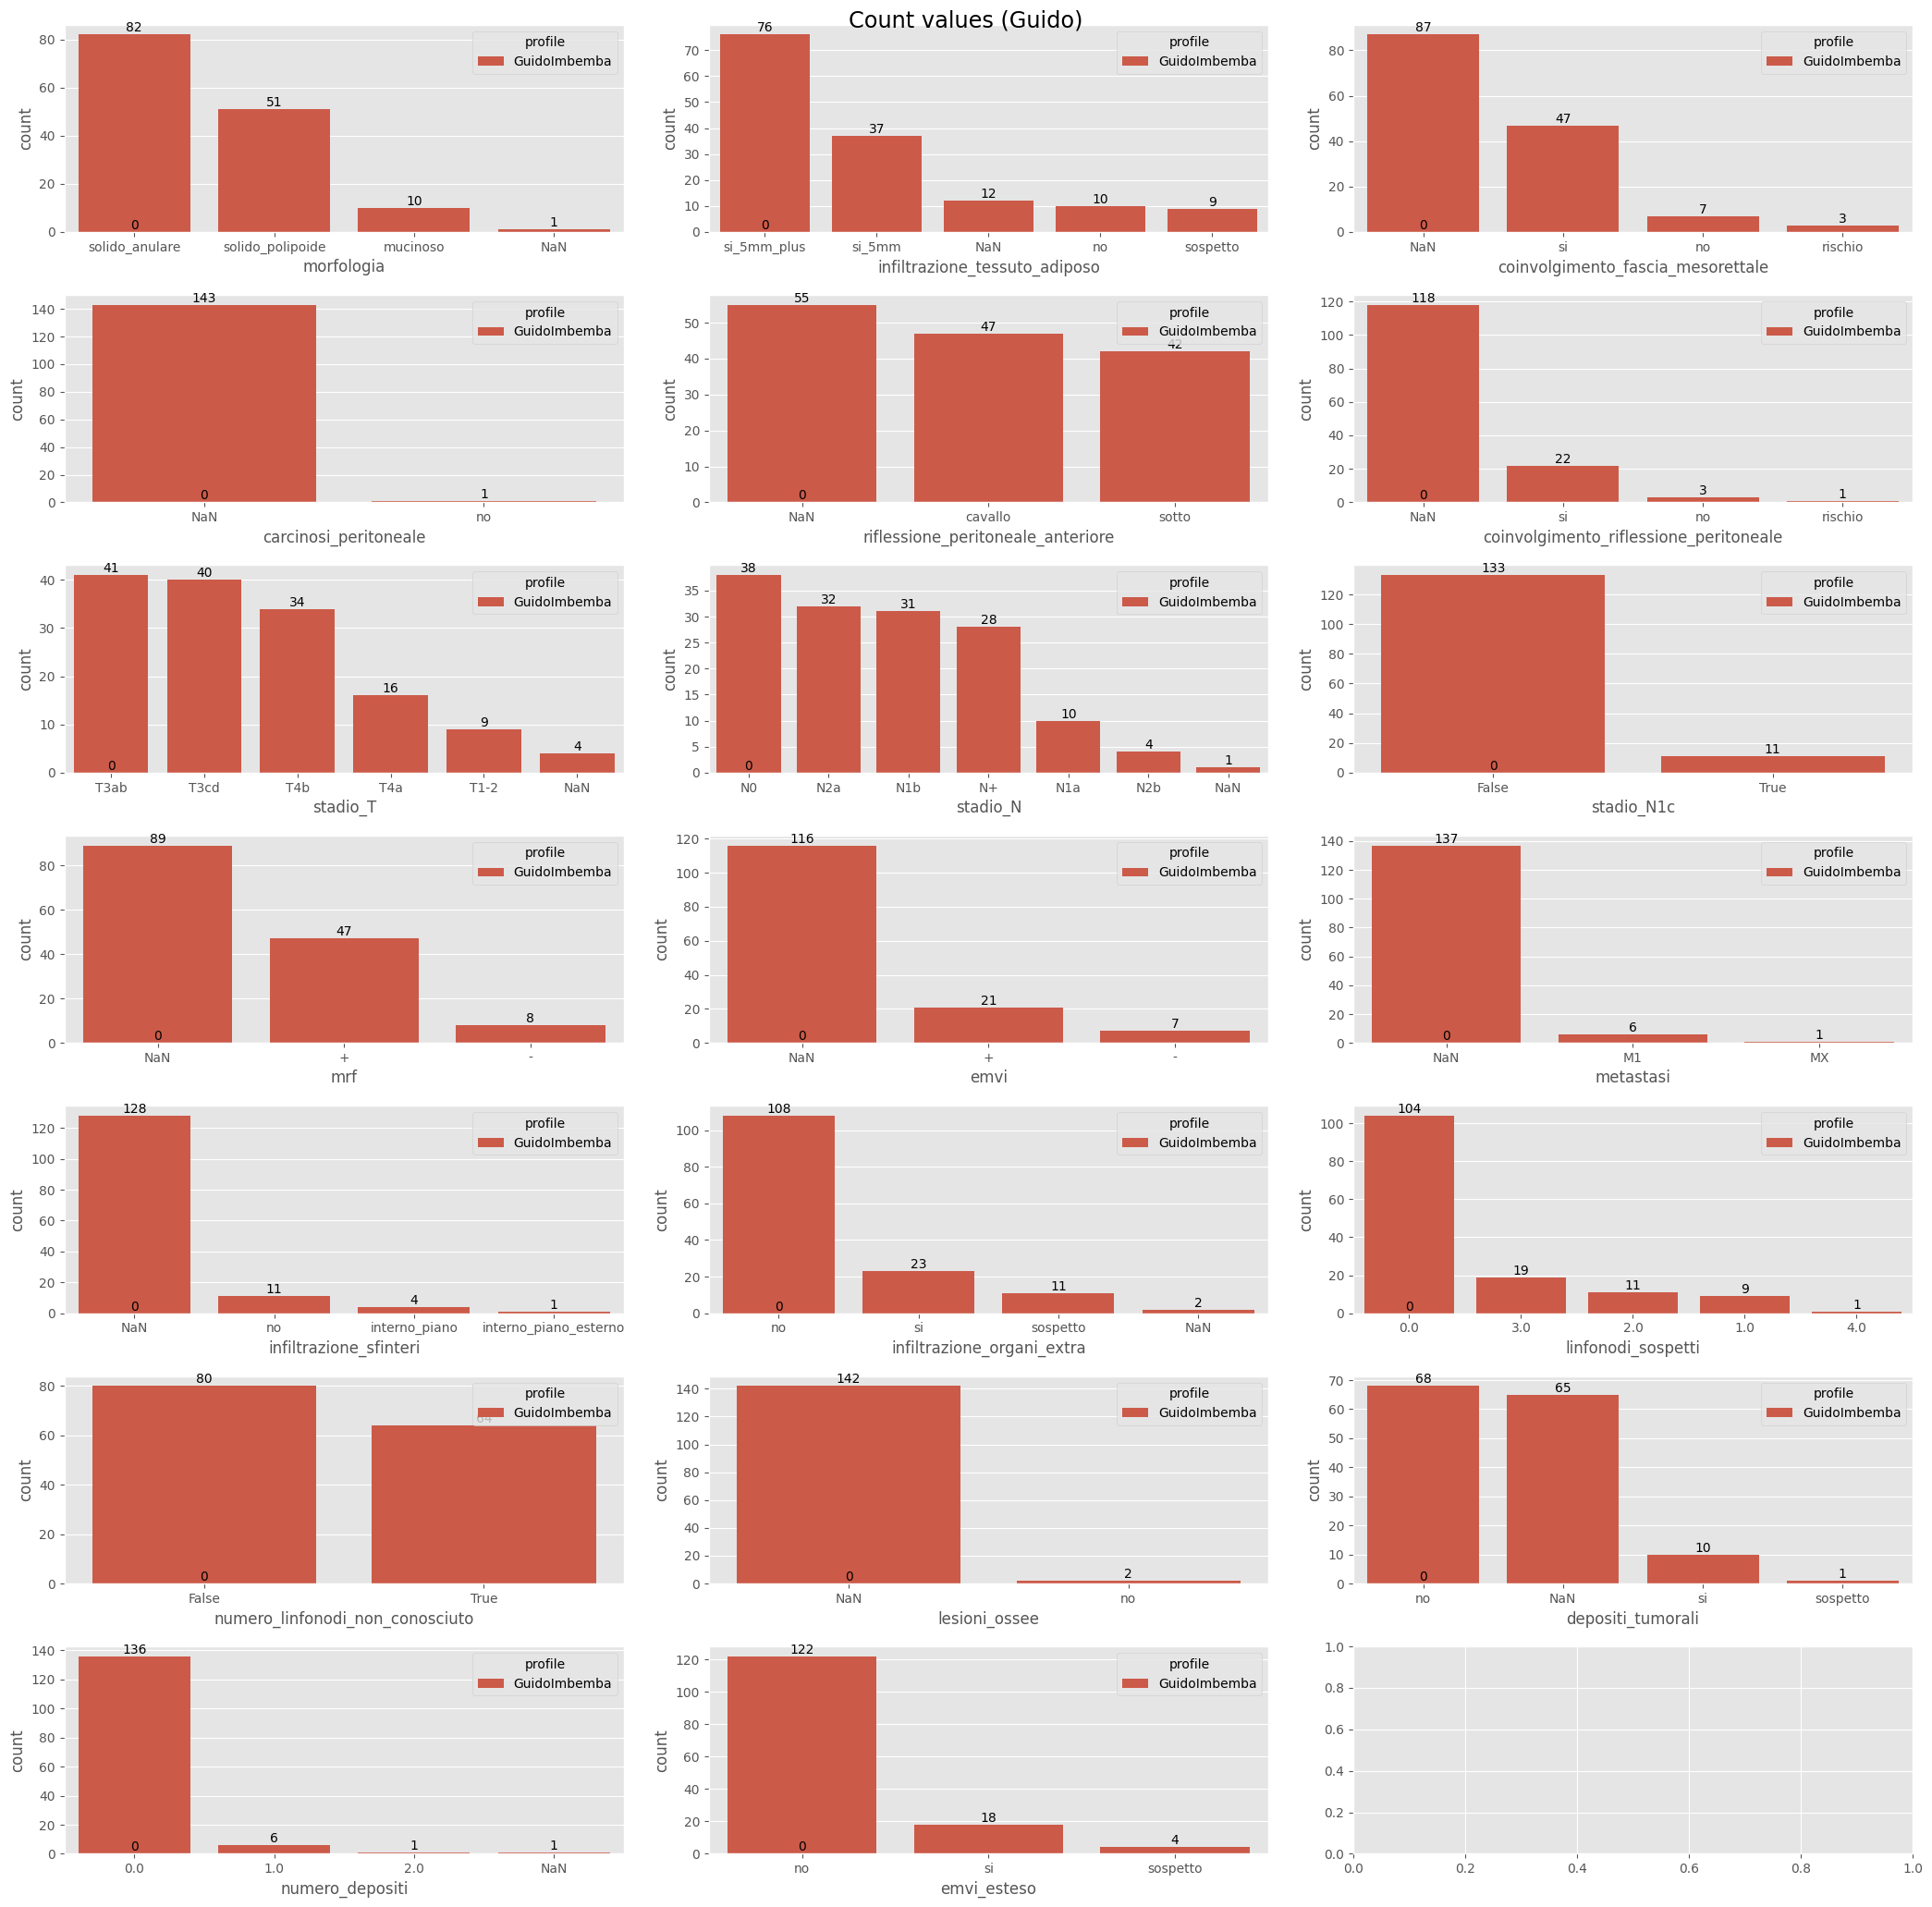

In [220]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, hue=hue_column)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

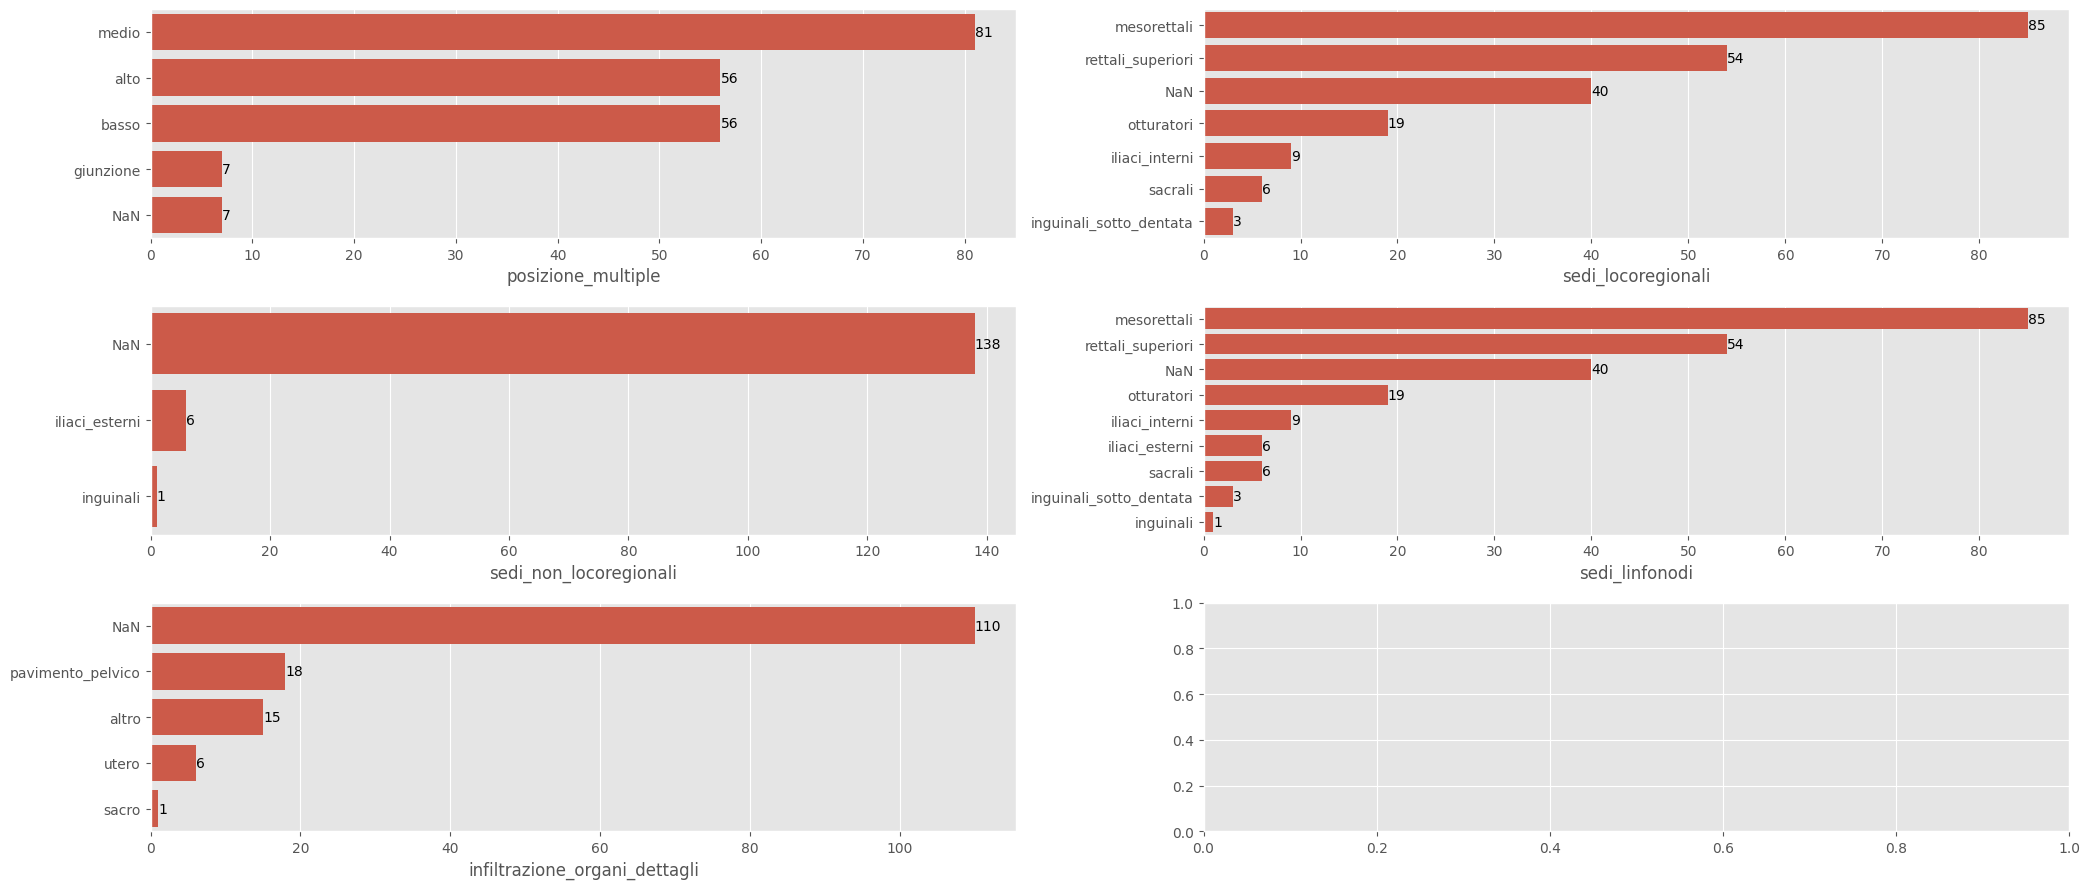

In [221]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
            
# Dettagli organi
dettagli_organi = {'NaN'}
altri_organi = set()
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN').value_counts().index:
    if s != 'NaN' and s != 'nan':
        d = ast.literal_eval(s)
        #print('---')
        dettagli_organi.update(d.keys())
        if 'altro' in d:
            altri_organi.add(d['altro'])
            
dettagli_organi_counts = {val: 0 for val in dettagli_organi}
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN'):
    if s == 'NaN' or s == 'nan':
        dettagli_organi_counts['NaN'] += 1
    else:
        d = ast.literal_eval(s)
        for key in dettagli_organi:
            if key in d:
                dettagli_organi_counts[key] += 1

counts['infiltrazione_organi_dettagli'] = dettagli_organi_counts
columns.append('infiltrazione_organi_dettagli')
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

Idea: uniamo sedi locoregionali e non locoregionali e manteniamo solo alcune classi: mesorettali, rettali_superiori, NaN, otturatori, iliaci. I restanti li metteremo in "altro".

Per quanto riguarda i dettagli dell'infiltrazione organi, teniamo solo le classi NaN, pavimento_pelvico, altro.

# Aggregazione / modifica delle colonne

In [222]:
palette_corrente = plt.rcParams['axes.prop_cycle'].by_key()['color']
print(palette_corrente)
display(sns.color_palette(palette_corrente))
new_color = palette_corrente[-2]

['#E24A33', '#348ABD', '#988ED5', '#777777', '#FBC15E', '#8EBA42', '#FFB5B8']


[(0.8862745098039215, 0.2901960784313726, 0.2),
 (0.20392156862745098, 0.5411764705882353, 0.7411764705882353),
 (0.596078431372549, 0.5568627450980392, 0.8352941176470589),
 (0.4666666666666667, 0.4666666666666667, 0.4666666666666667),
 (0.984313725490196, 0.7568627450980392, 0.3686274509803922),
 (0.5568627450980392, 0.7294117647058823, 0.25882352941176473),
 (1.0, 0.7098039215686275, 0.7215686274509804)]

In [223]:
# Dettagli infiltrazione organi
infiltrazione_organi_dettagli_new = []
for s in data_clean_guido.infiltrazione_organi_dettagli.fillna('NaN'):
    dettagli = []
    if s == 'NaN':
        infiltrazione_organi_dettagli_new.append(str(dettagli))
    else:
        d = ast.literal_eval(s)
        if 'pavimento_pelvico' in d:
            dettagli.append('pavimento_pelvico')
        if ('altro' in d) or ('utero' in d) or ('sacro' in d):
            dettagli.append('altro')
        infiltrazione_organi_dettagli_new.append(str(dettagli))
data_clean_guido.loc[:, 'infiltrazione_organi_dettagli'] = infiltrazione_organi_dettagli_new

#print(data_clean_guido.infiltrazione_organi_dettagli.value_counts())

# Sedi linfonodi
sedi_linfonodi_new = []
for s in data_clean_guido.sedi_linfonodi:
    sedi = ast.literal_eval(s)
    sedi_new = set()
    for sede in sedi:
        if sede in ['mesorettali', 'rettali_superiori', 'otturatori']:
            sedi_new.add(sede)
        elif sede in ['iliaci_comuni', 'iliaci_interni', 'iliaci_esterni']:
            sedi_new.add('iliaci')
        else:
            sedi_new.add('altro')
    sedi_linfonodi_new.append(str(list(sedi_new)))
data_clean_guido.loc[:, 'sedi_linfonodi'] = sedi_linfonodi_new
#print(data_clean_guido.sedi_linfonodi.value_counts())

# Coinvolgimento fascia mesorettale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['coinvolgimento_fascia_mesorettale'] == 'rischio', 'coinvolgimento_fascia_mesorettale'] = 'si'
#print(data_clean_guido.coinvolgimento_fascia_mesorettale.value_counts())

# Coinvolgimento riflessione peritoneale. Trasformiamo rischio in si
data_clean_guido.loc[data_clean_guido['coinvolgimento_riflessione_peritoneale'] == 'rischio', 'coinvolgimento_riflessione_peritoneale'] = 'si'
#print(data_clean_guido.coinvolgimento_riflessione_peritoneale.value_counts())

# Infiltrazione sfinteri. Trasformiamo la posizione in si. per otenere una classe (si/no/NaN)
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno_piano', 'infiltrazione_sfinteri'] = 'si'
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno', 'infiltrazione_sfinteri'] = 'si'
data_clean_guido.loc[data_clean_guido['infiltrazione_sfinteri'] == 'interno_piano_esterno', 'infiltrazione_sfinteri'] = 'si'
#print(data_clean_guido.infiltrazione_sfinteri.value_counts())

# Emvi. Trasformiamo sospetto in si
data_clean_guido.loc[data_clean_guido['emvi_esteso'] == 'sospetto', 'emvi_esteso'] = 'si'
#print(data_clean_guido.emvi_esteso.value_counts())

# Depositi tumorali. Trasformiamo sospetto in si
data_clean_guido.loc[data_clean_guido['depositi_tumorali'] == 'sospetto', 'depositi_tumorali'] = 'si'
#print(data_clean_guido.depositi_tumorali.value_counts())

data_plot = data_clean_guido.fillna('NaN')

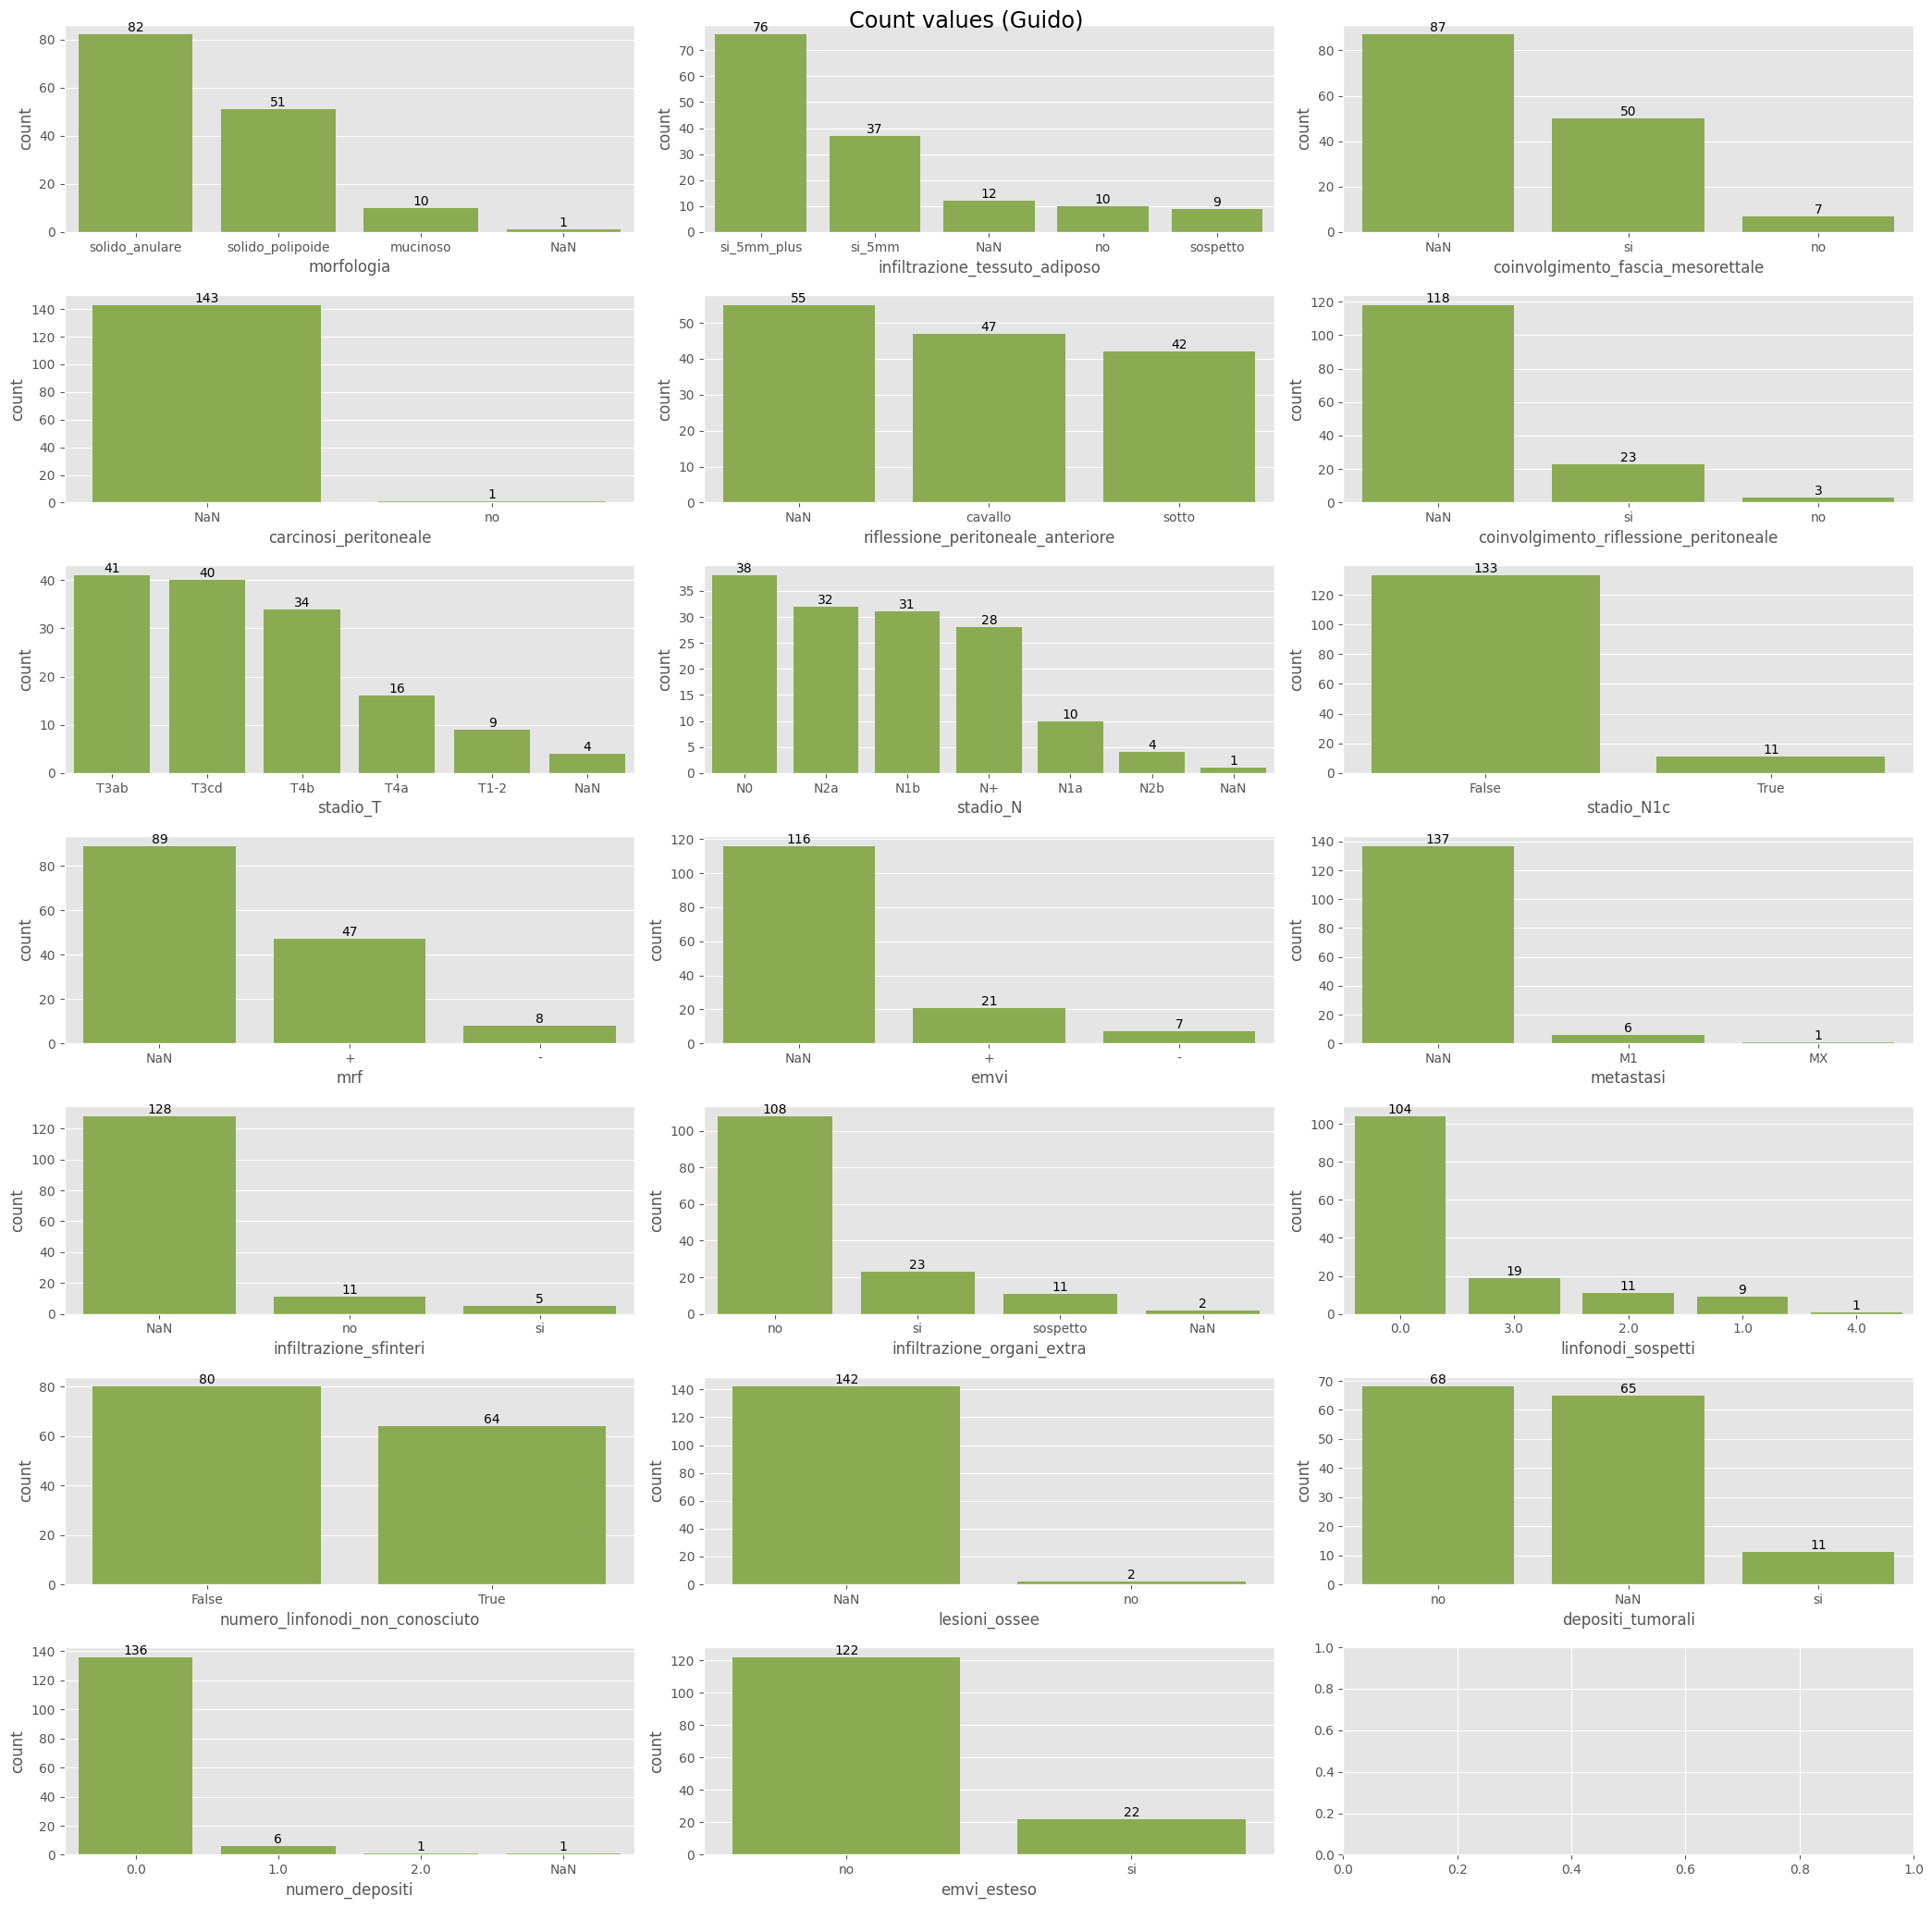

In [224]:
columns_plot = ['morfologia', 'infiltrazione_tessuto_adiposo', 'coinvolgimento_fascia_mesorettale',
                'carcinosi_peritoneale', 'riflessione_peritoneale_anteriore', 'coinvolgimento_riflessione_peritoneale',
                'stadio_T', 'stadio_N', 'stadio_N1c',
                'mrf', 'emvi', 'metastasi',
                'infiltrazione_sfinteri', 'infiltrazione_organi_extra',
                'linfonodi_sospetti', 'numero_linfonodi_non_conosciuto', 'lesioni_ossee',
                'depositi_tumorali', 'numero_depositi', 'emvi_esteso']

#hue_column = None
#columns_plot = [hue_column] + columns_plot

n_columns = 3
n_rows, r = divmod(len(columns_plot), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(n_columns*7, n_rows*3))
fig.suptitle("Count values (Guido)", fontsize='xx-large')

for i, col in enumerate(columns_plot):
    ax=axes[i//n_columns][i%n_columns]
    sns.countplot(data=data_plot, x=col, order=data_plot[col].value_counts().index, ax=ax, color=new_color)
    # Add values on top of bars
    for p in ax.patches:
        y_text = int(p.get_height())
        x_text = p.get_x() + p.get_width() / 2
        ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')

plt.tight_layout()
#plt.savefig("distribuzione_featurse_per_annotatore.png", dpi=300, bbox_inches='tight', transparent=False)
plt.show()

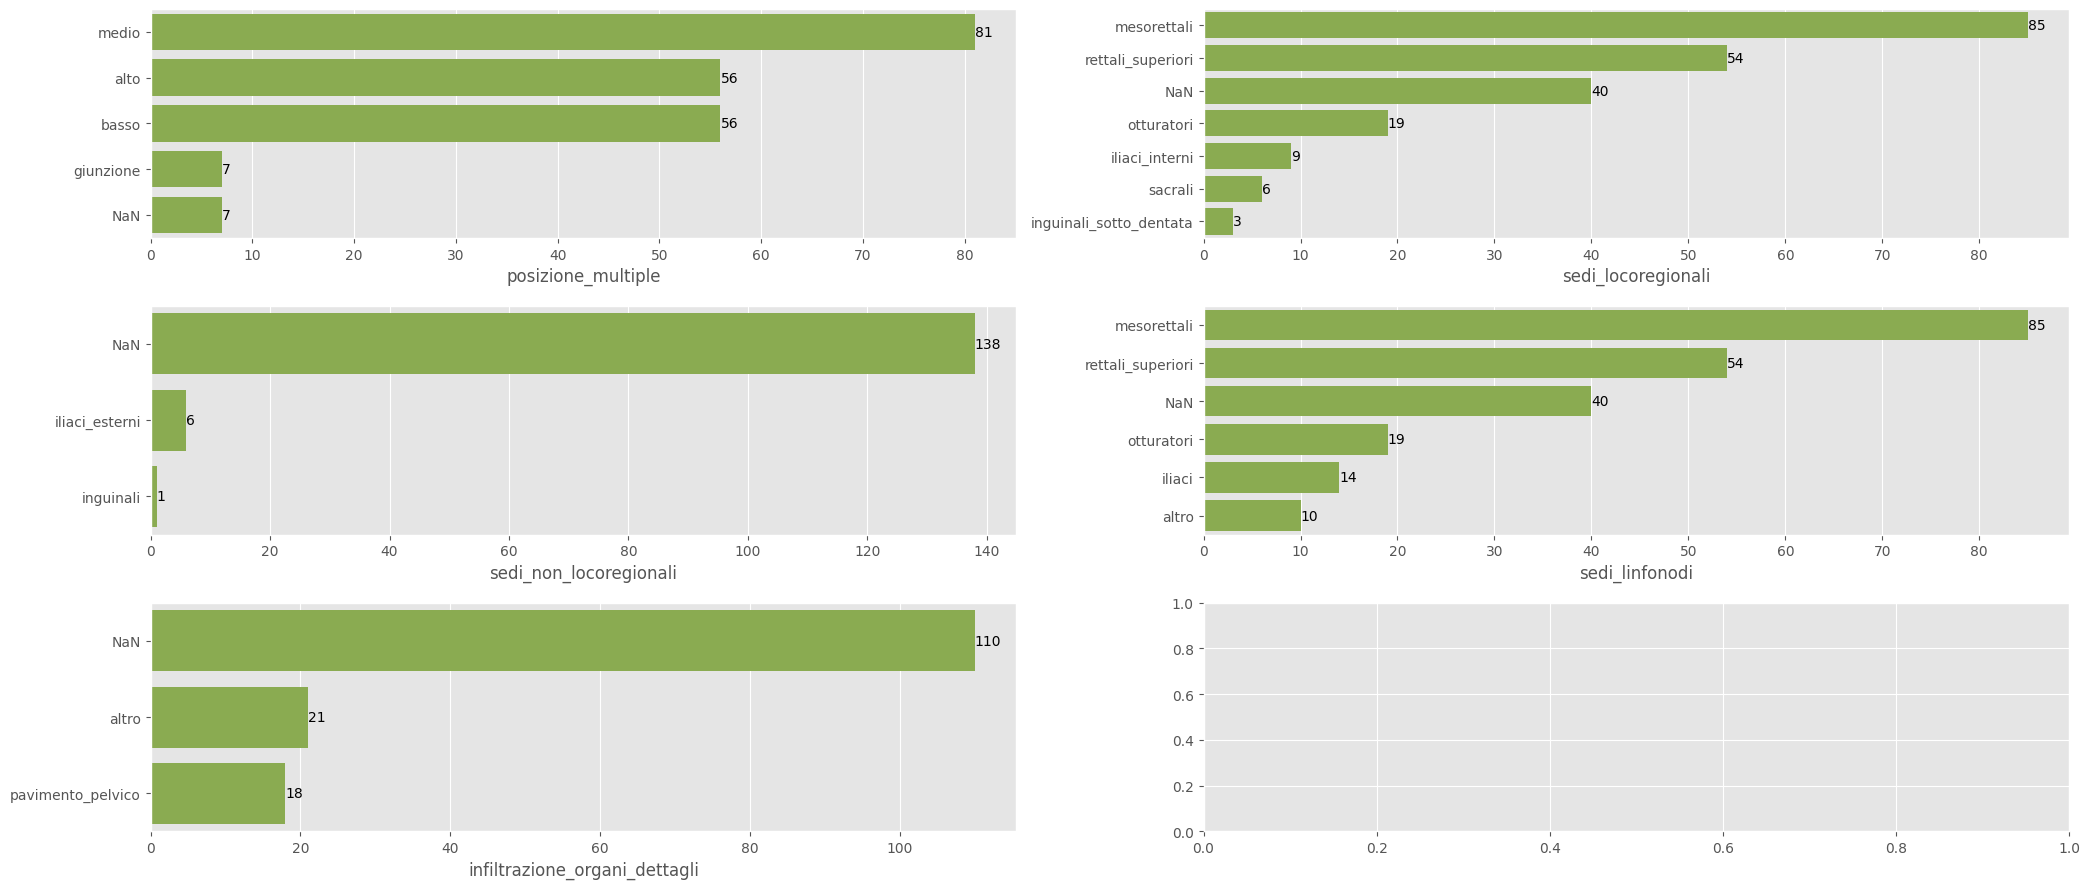

In [225]:
# Analisi posizione, sedi locoregionali, sedi non locoregionali
columns = ['posizione_multiple', 'sedi_locoregionali', 'sedi_non_locoregionali', 'sedi_linfonodi', 'infiltrazione_organi_dettagli']

possible_values = {col: ['NaN'] for col in columns}

for col in columns:
    for s in data_plot[col].value_counts().index:
        possible_values[col] += ast.literal_eval(s)
    possible_values[col] = list(set(possible_values[col]))    


counts = {
    col: {val: 0 for val in possible_values[col]}
    for col in columns
}
for col in columns:
    for s in data_plot[col]:
        value_list = ast.literal_eval(s)
        for value in possible_values[col]:
            if value in value_list:
                counts[col][value] += 1
        if value_list == []:
            counts[col]['NaN'] += 1
            
         
         
n_columns = 2
n_rows, r = divmod(len(columns), n_columns)
if r != 0:
    n_rows += 1
            
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*3))
orientation = 'h'
for i, col in enumerate(columns):
    ax=axes[i//n_columns][i%n_columns]
    series = pd.Series(counts[col], name=col).sort_values(ascending=False)
    sns.barplot(data=series, ax=ax, orient=orientation, color=new_color)
    # Add values on top of bars
    if orientation == 'v':
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
    if orientation == 'h':
        for p in ax.patches:
            x_text = p.get_width()
            y_text = p.get_y() + p.get_height() / 2
            ax.text(x=x_text, y=y_text, s=f'{int(x_text)}', va='center', ha='left')

plt.tight_layout()
plt.show()

## Colonne target numeriche

In [226]:
data_clean_guido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 46 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      144 non-null    int64  
 1   profile                                 144 non-null    object 
 2   discrepanze_rilevate                    144 non-null    object 
 3   motivazioni_discrepanze                 144 non-null    object 
 4   radiologist                             144 non-null    object 
 5   patient_id                              144 non-null    int64  
 6   sesso                                   143 non-null    object 
 7   data_nascita                            144 non-null    object 
 8   interpretazioni                         59 non-null     object 
 9   report_text                             144 non-null    object 
 10  morfologia                              143 non-null    object

In [227]:
colonne_target_numeriche = ['ore_inizio', 'ore_fine', 'dimensione_dll',
    'dimensione_dap', 'spessore_parietale', 'estensione_cranio_caudale',
    'distanza_oai', 'distanza_minima_fascia_ore',
    'linfonodi_sospetti', 'numero_depositi']

In [228]:
display(data_clean_guido[colonne_target_numeriche].describe().T)
display(data_clean_guido[colonne_target_numeriche].dtypes)

,count,mean,std,min,25%,50%,75%,max
ore_inizio,57.0,9.368421,3.538722,1.0,6.00,12.0,12.00,12.0
ore_fine,57.0,10.192982,3.492025,1.0,11.00,12.0,12.00,12.0
dimensione_dll,12.0,42.250000,26.330504,15.0,21.50,40.0,49.75,105.0
dimensione_dap,9.0,53.111111,32.643699,25.0,31.00,38.0,53.00,120.0
spessore_parietale,25.0,20.280000,13.030477,7.0,13.00,15.0,22.00,60.0
estensione_cranio_caudale,135.0,48.533333,17.460317,18.0,35.50,47.0,55.00,130.0
distanza_oai,132.0,44.954545,29.293947,0.0,23.75,48.5,65.00,120.0
distanza_minima_fascia_ore,7.0,6.000000,4.760952,1.0,2.00,5.0,10.00,12.0
linfonodi_sospetti,144.0,0.638889,1.125739,0.0,0.00,0.0,1.00,4.0
numero_depositi,143.0,0.055944,0.259366,0.0,0.00,0.0,0.00,2.0


ore_inizio                    float64
ore_fine                      float64
dimensione_dll                float64
dimensione_dap                float64
spessore_parietale            float64
estensione_cranio_caudale     float64
distanza_oai                  float64
distanza_minima_fascia_ore    float64
linfonodi_sospetti            float64
numero_depositi               float64
dtype: object

escludere le segenti colonne perchè hanno troppi valori nulli:
- dimensione_dll
- dimensione_dap
- distanza_minima_fascia_ore

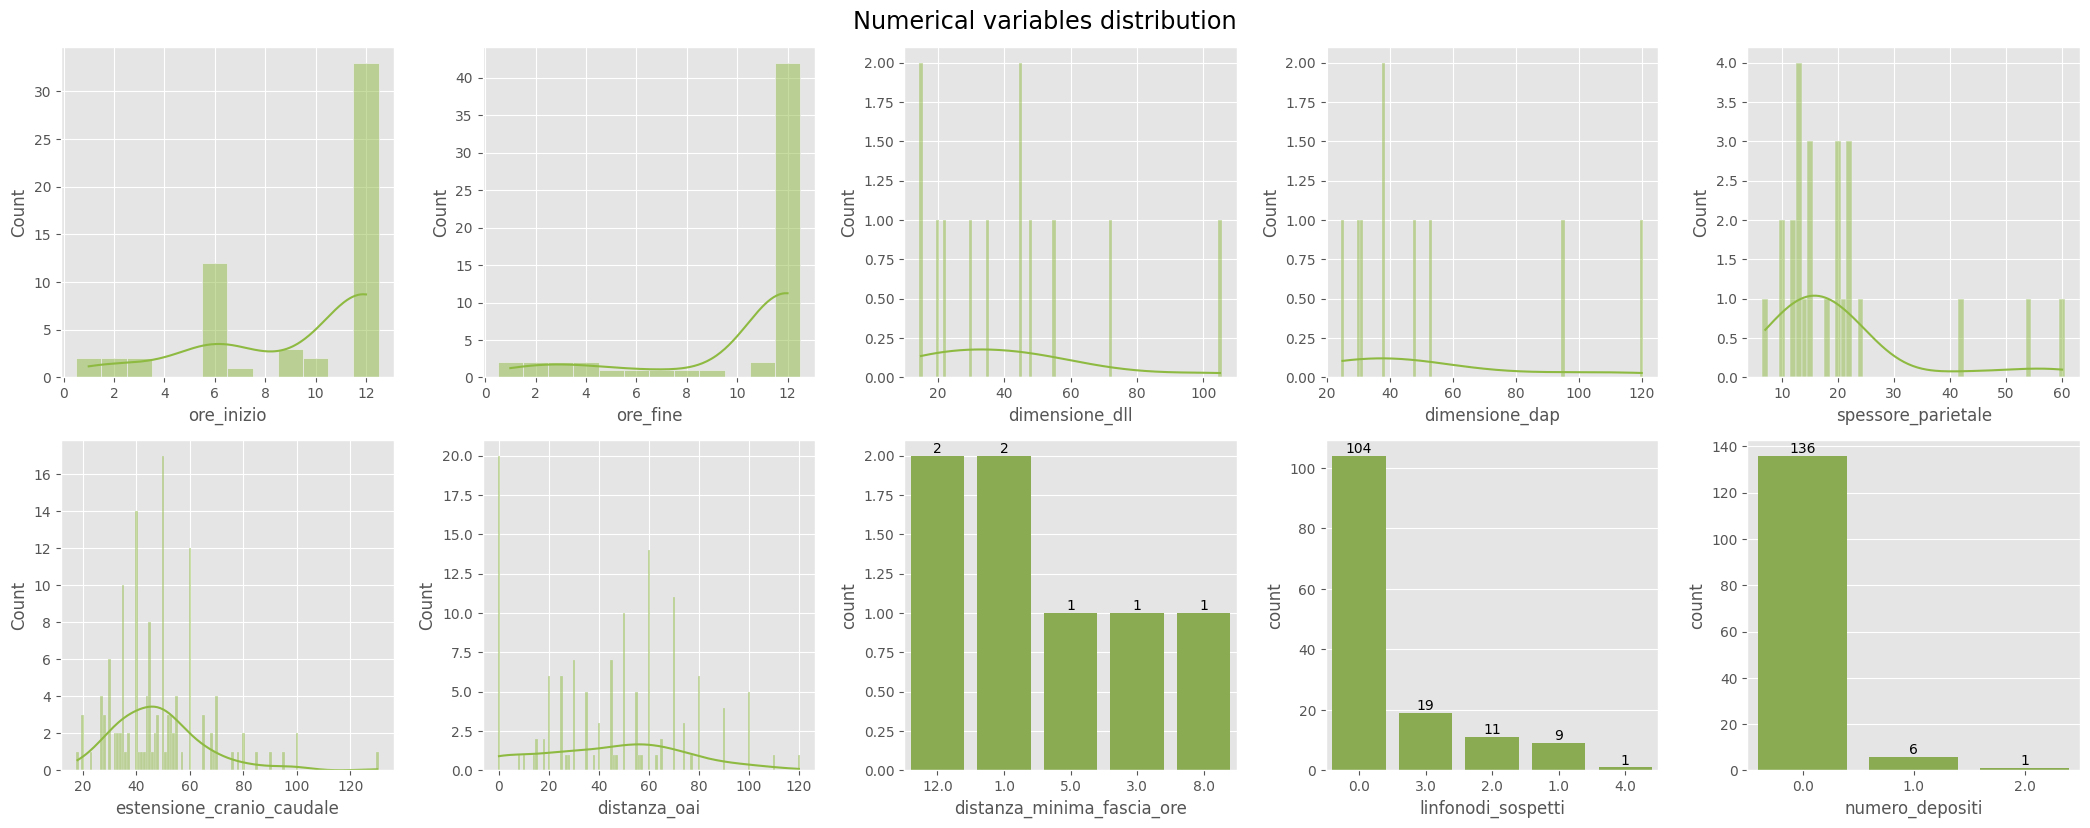

In [229]:
n_columns = 5
n_rows, r = divmod(len(colonne_target_numeriche), n_columns)
if r != 0:
    n_rows += 1
    
fig, axes = plt.subplots(n_rows, n_columns, figsize=(21, n_rows*21/n_columns))
fig.suptitle("Numerical variables distribution", fontsize='xx-large')

for i, col in enumerate(colonne_target_numeriche):
    ax=axes[i//n_columns][i%n_columns]
    if len(data_clean_guido[col].value_counts()) > 5:
        sns.histplot(data=data_clean_guido, x=col, ax=ax, color=new_color, discrete=True, stat='count', kde=True)
    else:
        sns.countplot(data=data_clean_guido, x=col, order=data_clean_guido[col].value_counts().index, ax=ax, color=new_color)
        # Add values on top of bars
        for p in ax.patches:
            y_text = int(p.get_height())
            x_text = p.get_x() + p.get_width() / 2
            ax.text(x=x_text, y=y_text, s=f'{y_text}', ha='center', va='bottom')
plt.tight_layout()
plt.show()